# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Changing directory for VSCode notebook
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import parismc
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



# Initialization

In [2]:
# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

Initializing waveform generator...
Creating GenerateEMRIWaveform class...


Done initializing waveform generator.


In [3]:
print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

Creating GravWaveAnalysis class...


In [4]:
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5


In [5]:
print("Generate data...")
data = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)

Generate data...


In [6]:
data_f = gwf.freq_wave(data)
snr_data = gwf.SNR(data_f)
print(f"SNR of data: {snr_data}")

SNR of data: 107.43944631400305


# Likelihood, Prior

In [7]:
def loglike(params):
    params = np.asarray(params)

    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2
        phiK = phiS + np.pi/3

        htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                            Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
        
        # htemp_reshape = np.asarray([htemp.get().real, -htemp.get().imag])
        # PSD_htemp = generate_PSD(waveform=htemp_reshape, dt=dt, noise_PSD=sensitivity_LWA,
        #          channels=["A", "E"], noise_kwargs={}, use_gpu=False)
        # inner_data_htemp = inner_product(waveform, htemp_reshape, PSD_htemp, dt)
        # inner_htemp = inner_product(htemp_reshape, htemp_reshape, PSD_htemp, dt)

        res = data - htemp

        res_f = gwf.freq_wave(res)
        inner_res = gwf.inner(res_f, res_f)
        # res_reshape = np.asarray([res.get().real, -res.get().imag])
        # PSD_res = generate_PSD(waveform=res_reshape, dt=dt, noise_PSD=sensitivity_LWA, channels=["A", "E"], noise_kwargs={}, use_gpu=False)
        # inner_res = inner_product(res_reshape, res_reshape, PSD_res, dt)
        calc_loglike = - 0.5 * inner_res

            
        log_likes[i] = calc_loglike
        

    return log_likes


In [8]:
# def loglike_alt(params):
#     params = np.asarray(params)

#     n_samples = params.shape[0]
#     log_likes = np.zeros(n_samples)

#     for i in range(n_samples):
#         logm1, logm2, a, p0, e0 = params[i]
#         m1 = 10**logm1
#         m2 = 10**logm2
#         phiK = phiS + np.pi/3

#         htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
#                             Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
        
#         res = data - htemp
#         res_f = gwf.freq_wave(res)
#         inner_res = gwf.inner(res_f, res_f)
#         calc_loglike = -0.5 * inner_res
#         # htemp_f = gwf.freq_wave(htemp)
#         # match_filt = gwf.inner(data_f, htemp_f)
#         # print('<x|h>:', match_filt)
#         # inner_temp = gwf.inner(htemp_f, htemp_f)
#         # print('<h|h>:', inner_temp)
#         # calc_loglike = match_filt - 0.5 * (inner_data + inner_temp)
#         # print(calc_loglike)
            
#         log_likes[i] = calc_loglike
        

#     return log_likes


In [8]:
def prior_transform(u):

    logm1lim = [5.999851037559485, 6.000148962440515]
    logm2lim = [1.4770378504576676, 1.4772046589816572]
    alim = [0.6997315972442014, 0.7002684027557985]
    p0lim = [7.498519407697586, 7.501480592302414]
    e0lim = [0.3999359060325742, 0.40006409396742587]


    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

In [9]:
loglike(np.array([[np.log10(m1), np.log10(m2), a, p0, e0]]))

array([-2.23224141e-18])

# Sampling

In [ ]:
print('Done setting up log-likelihood and prior.')
print('Setting up ParisMC sampler...')
config = parismc.SamplerConfig(
    merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
    alpha=10000,                    # Use recent samples for weighting. 
    trail_size=int(1e3),          # Maximum trials per iteration
    boundary_limiting=True,        # Enable boundary constraints
    use_beta=True,                # Use beta correction for boundaries
    integral_num=int(1e5),        # MC samples for beta estimation
    gamma=500,                    # Covariance update frequency
    exclude_scale_z=10,       # No exclusion based on weights
    use_pool=False,               # Set to True for multiprocessing
    n_pool=4                      # Number of processes (if use_pool=True)
)

In [ ]:
print('Done setting up ParisMC sampler.')
print('Setting up initial covariance matrix...')

#Changing directory and loading covariance matrix
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

import pickle
with open('cov_matrix_intrinsic.pkl', 'rb') as f:
    cov_matrix = pickle.load(f)

ndim = 5
n_seed = 1
init_cov_list = [cov_matrix for _ in range(n_seed)]
print('Done setting up initial covariance matrix.')
print('Initializing sampler...')
sampler = parismc.Sampler(
    ndim=ndim, 
    n_seed=n_seed,
    log_density_func=loglike,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)
print('Done initializing sampler.')



# Visualization

In [9]:
# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

# Add it to Python path

sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

In [10]:
sampler = parismc.Sampler.load_state('./paris_intrinsic4/sampler_state.pkl')

In [11]:
logden_list = sampler.searched_log_densities_list[0]
len(logden_list[~np.isfinite(logden_list)])

6924

In [12]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

In [10]:
import pickle

with open('cov_matrix_intrinsic_new.pkl', 'rb') as f:
    cov_mat = pickle.load(f)

with open('ns_intrinsic2.pkl', 'rb') as f:
    dres = pickle.load(f)

dynesty_samples = dres.samples
dynesty_weights = dres.importance_weights()


In [15]:
from scipy.stats import multivariate_normal

# Generate samples from multivariate normal
n_fisher_samples = 10000
fisher_samples = multivariate_normal.rvs(
    mean=param_true,  # [log_m1, log_m2, a, p0, e0]
    cov=cov_mat,      # Full covariance matrix
    size=n_fisher_samples
)

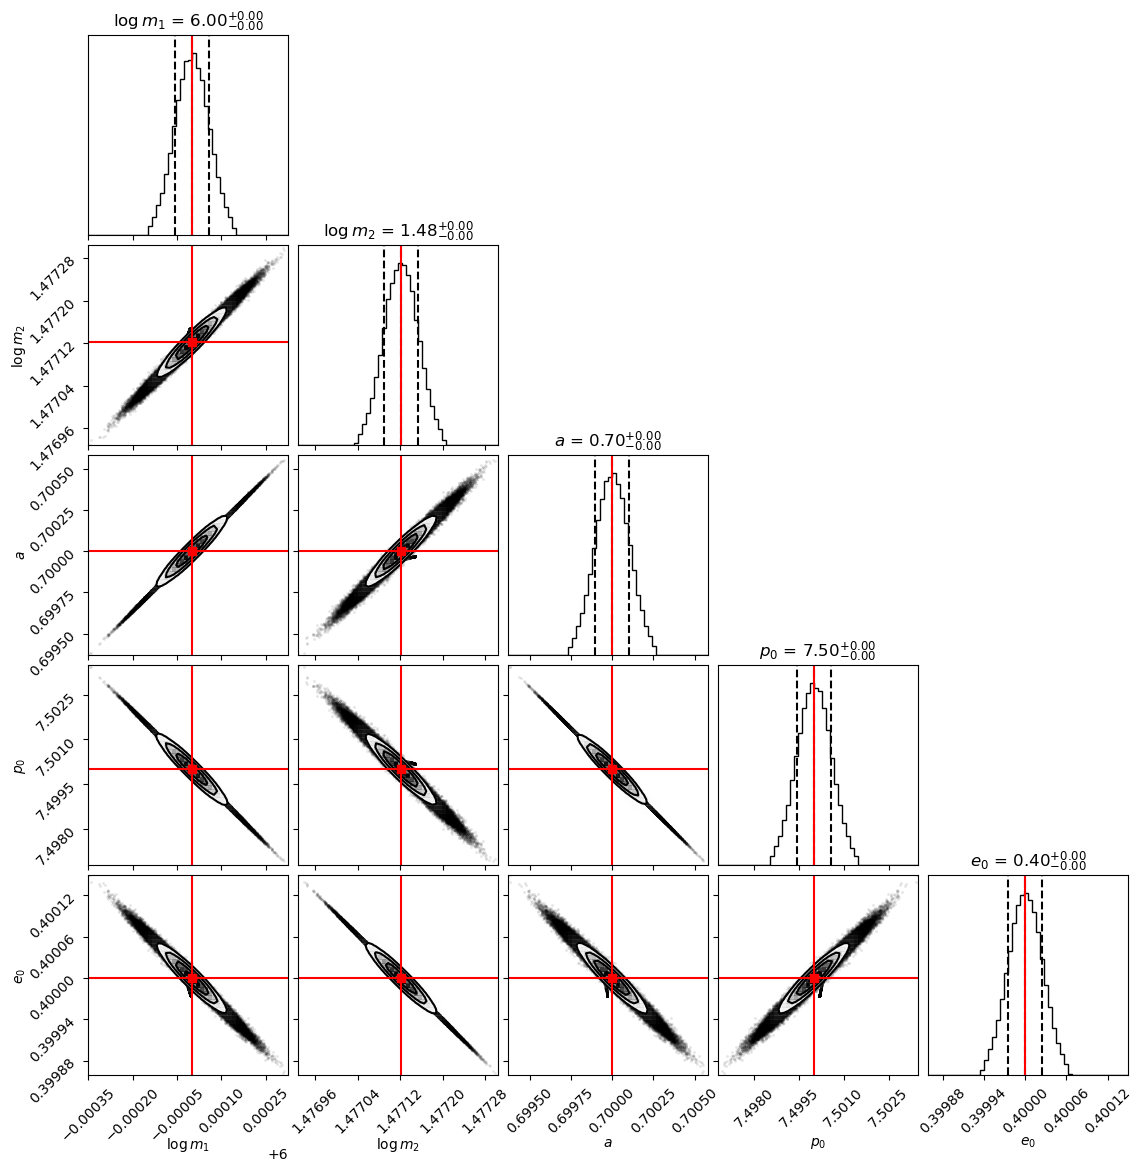

In [16]:
import corner
labels = [r'$\log{m_1}$', r'$\log{m_2}$',r'$a$',r'$p_0$',r'$e_0$']

fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma and median
    smooth=True,
    bins=50,
)

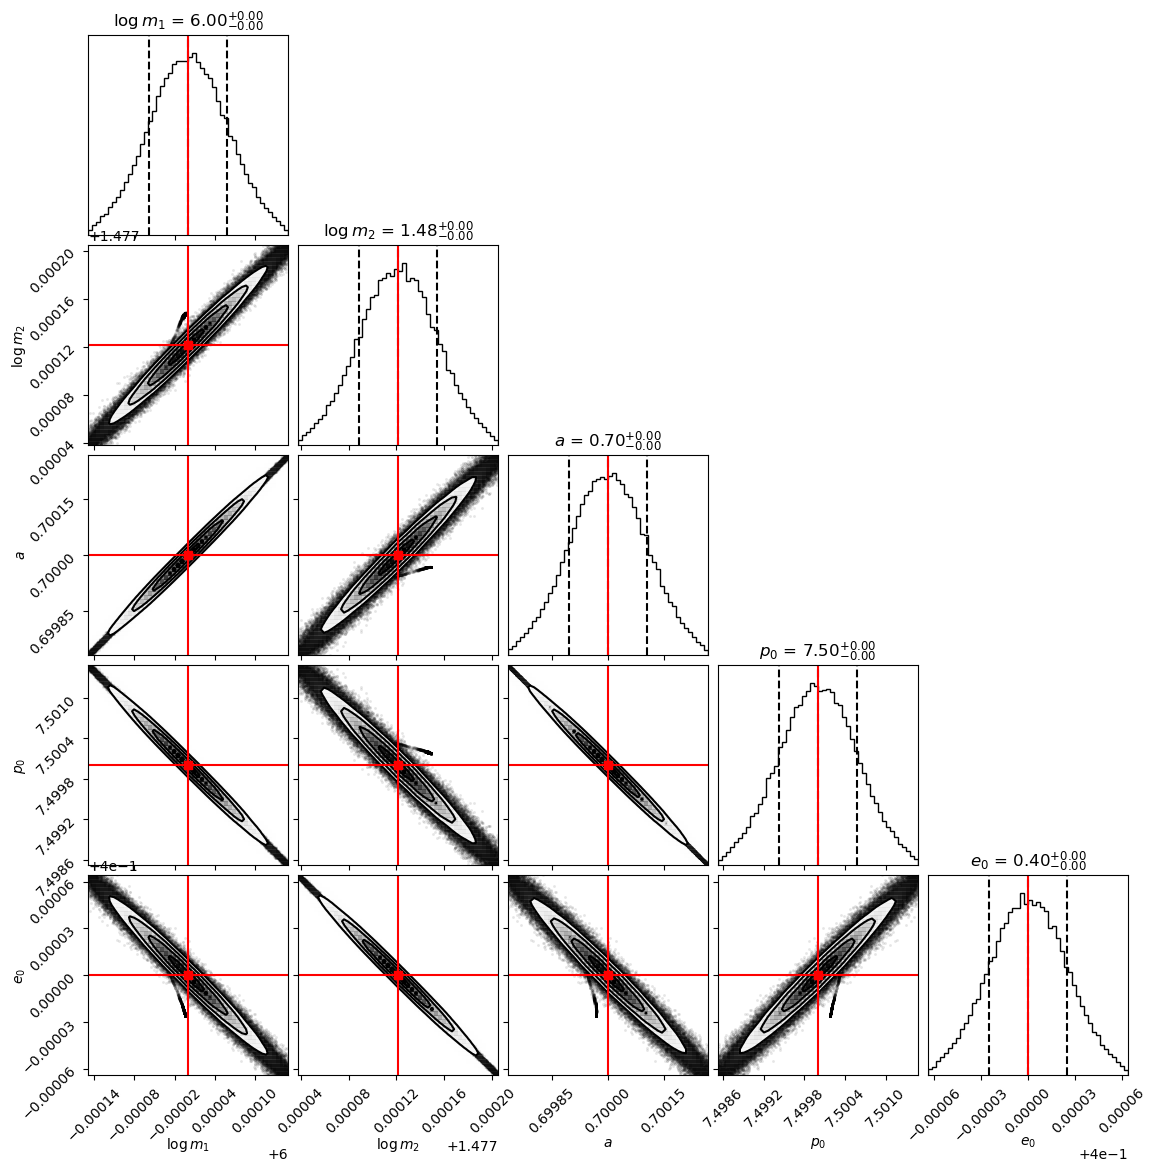

In [17]:
param_ranges = [(5.999851037559485, 6.000148962440515),
    (1.4770378504576676, 1.4772046589816572),
    (0.6997315972442014, 0.7002684027557985),
    (7.498519407697586, 7.501480592302414),
    (0.3999359060325742, 0.40006409396742587)]

fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma and median
    smooth=True,
    bins=50,
    range=param_ranges
)

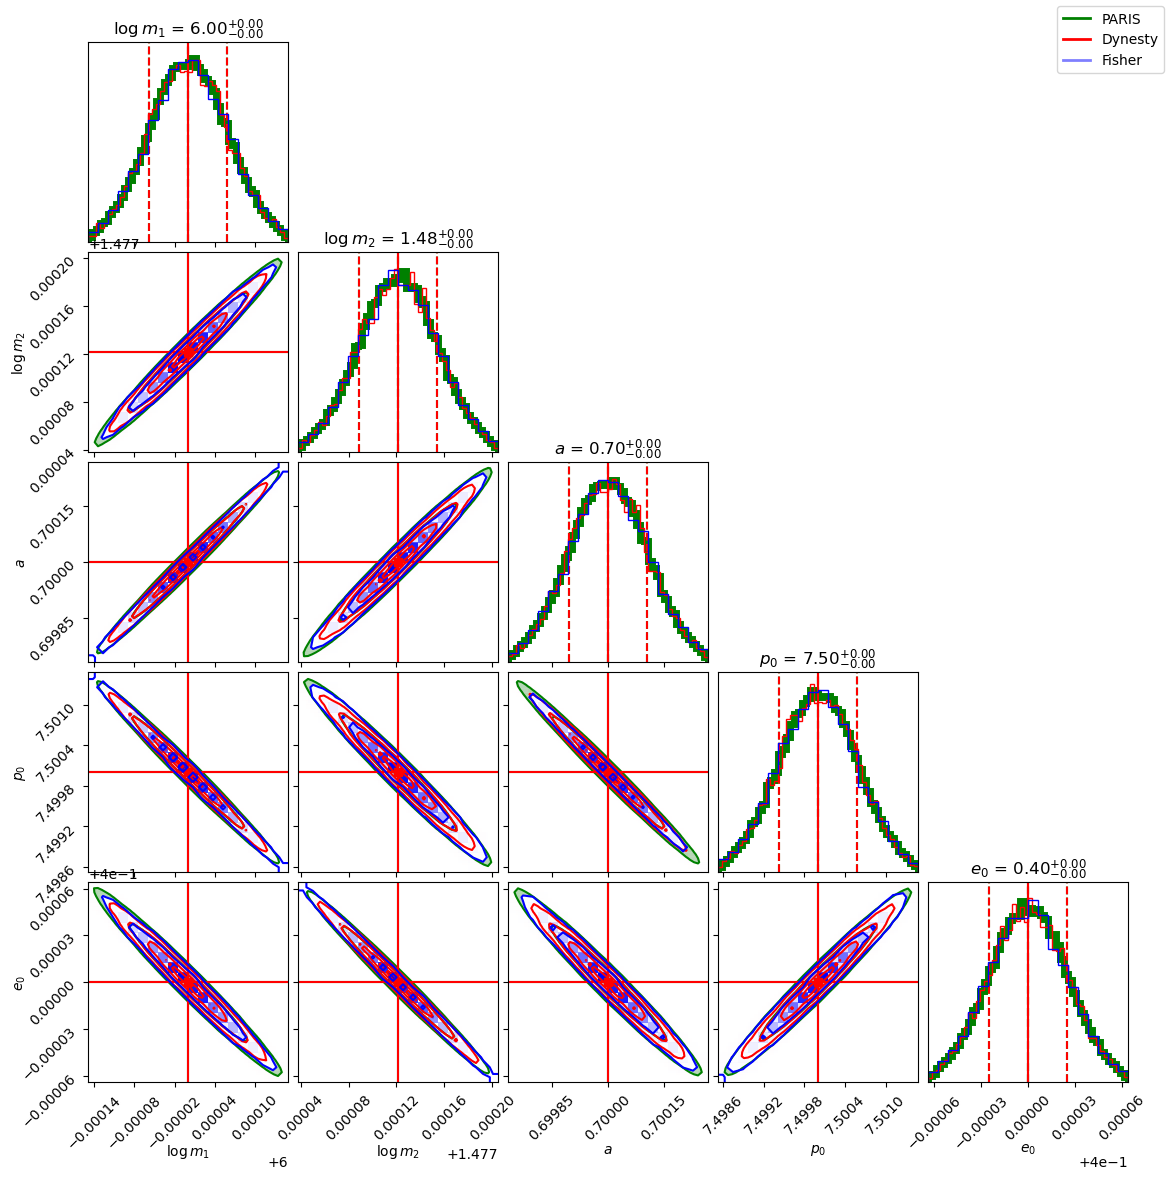

In [18]:
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='green',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=50,
    plot_datapoints=False,
    plot_density= True,
    levels=[0.68, 0.95],
    hist_kwargs={"density": True, 'linewidth': 5},
    linewidth=5,
    fill_contours=True,
    range = param_ranges
)

corner.corner(
    dynesty_samples,
    weights=dynesty_weights,
    fig=fig,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='red',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=50,
    plot_datapoints=False,
    hist_kwargs={"density": True},
    range = param_ranges
)

# Overlay Fisher ellipses
corner.corner(
    fisher_samples,
    fig=fig,
    color='blue',
    plot_datapoints=False,
    plot_density=True,
    levels=[0.68, 0.95],
    alpha=0.5,
    hist_kwargs={"density": True},
    range = param_ranges
)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='PARIS'),
    Line2D([0], [0], color='red', lw=2, label='Dynesty'),
    Line2D([0], [0], color='blue', lw=2, label='Fisher', alpha=0.5)
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)

In [11]:
sigmas = []
for i in range(5):
    sigma_i = np.sqrt(cov_mat[i, i])
    sigmas.append(sigma_i)

In [14]:
param_range = []
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
for i in range(5):
    param_min = param_true[i] - 8*sigmas[i]
    param_max = param_true[i] + 8*sigmas[i]
    param_range.append([param_min, param_max])

In [15]:
param_range

[[5.999523320190352, 6.000476679809648],
 [1.476854361081279, 1.4773881483580458],
 [0.6991411111814447, 0.7008588888185552],
 [7.495262104632274, 7.504737895367726],
 [0.3997948993042373, 0.40020510069576276]]